# LightGBM Baseline
Baseline ML theo pipeline TLSTM/LSTM, danh gia Accuracy, Macro F1, AUC, QWK.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, RobustScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    cohen_kappa_score,
    log_loss,
    confusion_matrix,
    classification_report,
)

try:
    import lightgbm as lgb
except Exception as exc:
    raise ImportError('Chua cai lightgbm. Hay chay: pip install lightgbm') from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def detect_kaggle_runtime() -> bool:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()

IN_KAGGLE = detect_kaggle_runtime()

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start

PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Artifact dir:', ARTIFACT_DIR)

Project root: /kaggle/working
Artifact dir: /kaggle/working/credit_rating_artifacts


In [2]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio', 'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin', 'net_profit_margin', 'asset_turnover',
    'roe', 'roa', 'operating_cashflow_ps', 'free_cashflow_ps'
]
TARGET_COL = 'rating_detail'
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']
INPUT_SIZE = 1
HORIZON = 1

def resolve_split_path(default_path, local_fallbacks=None):
    candidates = [Path(default_path)]
    for p in (local_fallbacks or []):
        p_obj = Path(p)
        candidates.append(PROJECT_ROOT / p_obj if not p_obj.is_absolute() else p_obj)
    if IN_KAGGLE:
        kaggle_root = Path('/kaggle/input')
        expanded = []
        for p in candidates:
            expanded.append(p)
            if not p.exists() and kaggle_root.exists():
                expanded.extend(kaggle_root.rglob(p.name))
        candidates = expanded
    seen = set()
    deduped = []
    for p in candidates:
        p = Path(p)
        key = str(p)
        if key not in seen:
            seen.add(key)
            deduped.append(p)
    for p in deduped:
        if p.exists():
            return p
    raise FileNotFoundError(f'Khong tim thay file split: {deduped}')

TRAIN_PATH = resolve_split_path('/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv', ['data/processed/train_augmented_timegan.csv'])
VAL_PATH = resolve_split_path('/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv', ['data/processed/val.csv'])
TEST_PATH = resolve_split_path('/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv', ['data/processed/test.csv'])

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df['__split__'] = 'train'
val_df['__split__'] = 'val'
test_df['__split__'] = 'test'
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

df = df.dropna(subset=[TARGET_COL]).copy()
target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    df[TARGET_COL] = target_as_num.astype(int)
    observed = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(v): i for i, v in enumerate(observed)}
    id_to_raw = {i: int(v) for v, i in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    tgt = df[TARGET_COL].astype(str).str.strip()
    observed = sorted(tgt.unique().tolist())
    ordered = [x for x in TARGET_ORDERED_LABELS if x in observed] if set(observed).issubset(set(TARGET_ORDERED_LABELS)) else observed
    raw_to_id = {v: i for i, v in enumerate(ordered)}
    id_to_raw = {i: v for v, i in raw_to_id.items()}
    df[TARGET_COL] = tgt.map(raw_to_id).astype(int)

n_classes = int(df[TARGET_COL].nunique())
label_ids = list(range(n_classes))

df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce', format='mixed')
if 'sector' not in df.columns:
    df['sector'] = 'UNKNOWN'
df['sector'] = df['sector'].fillna('UNKNOWN').astype(str)
sector_encoder = LabelEncoder()
df['sector_id'] = sector_encoder.fit_transform(df['sector'])

train_mask = df['__split__'].eq('train')
stats_ref = df.loc[train_mask].copy() if train_mask.any() else df.copy()

for c in FINANCIAL_FEATURES:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    med = stats_ref[c].median() if stats_ref[c].notna().any() else 0.0
    df[c] = df[c].fillna(float(0.0 if pd.isna(med) else med))

for c in FINANCIAL_FEATURES:
    lo = stats_ref[c].quantile(0.01)
    hi = stats_ref[c].quantile(0.99)
    if pd.notna(lo) and pd.notna(hi):
        df[c] = df[c].clip(float(lo), float(hi))

df = df.sort_values(['ticker', 'rating_date']).reset_index(drop=True)
for c in FINANCIAL_FEATURES:
    df[f'{c}_delta'] = df.groupby('ticker')[c].diff().fillna(0.0)

MODEL_FEATURES = FINANCIAL_FEATURES + [f'{c}_delta' for c in FINANCIAL_FEATURES]

scaler = RobustScaler()
scaler.fit(df.loc[df['__split__'].eq('train'), MODEL_FEATURES].values)
df[MODEL_FEATURES] = scaler.transform(df[MODEL_FEATURES].values)

def build_padded_window(values, target_idx, input_size):
    if target_idx <= 0:
        x_raw = values[:1]
    else:
        x_raw = values[max(0, target_idx - input_size):target_idx]
    if x_raw.shape[0] == 0:
        x_raw = values[:1]
    if x_raw.shape[0] >= input_size:
        return x_raw[-input_size:]
    pad = np.repeat(x_raw[[0]], input_size - x_raw.shape[0], axis=0)
    return np.concatenate([pad, x_raw], axis=0)

WINDOW_FEATURES = []
for step in range(INPUT_SIZE):
    lag = INPUT_SIZE - step
    for c in MODEL_FEATURES:
        WINDOW_FEATURES.append(f'{c}_t-{lag}')

TABULAR_FEATURES = WINDOW_FEATURES + ['last_y_id', 'sector_id']

def build_tabular_samples(frame, input_size=8, horizon=1):
    out = {'train': [], 'val': [], 'test': []}
    for _, g in frame.groupby('ticker'):
        g = g.sort_values('rating_date').reset_index(drop=True)
        vals = g[MODEL_FEATURES].values.astype(np.float32)
        ys = g[TARGET_COL].values.astype(int)
        sec = g['sector_id'].values.astype(int)
        sp = g['__split__'].astype(str).str.lower().values
        n = len(g)
        if n >= input_size + horizon:
            for i in range(n - input_size - horizon + 1):
                t = i + input_size
                x_window = vals[i:i+input_size]
                feat = x_window.reshape(-1)
                row = np.concatenate([feat, np.array([ys[i+input_size-1], sec[t]], dtype=np.float32)])
                out[sp[t]].append((row, int(ys[t])))
        else:
            t = n - 1
            x_window = build_padded_window(vals, t, input_size)
            feat = x_window.reshape(-1)
            row = np.concatenate([feat, np.array([ys[max(0, t-1)], sec[t]], dtype=np.float32)])
            out[sp[t]].append((row, int(ys[t])))
    return out

samples = build_tabular_samples(df, input_size=INPUT_SIZE, horizon=HORIZON)
for split_name in ['train', 'val', 'test']:
    if len(samples[split_name]) == 0:
        raise ValueError(f'Split {split_name} khong co mau sau khi tao window; kiem tra lai du lieu va INPUT_SIZE.')

def to_xy(items):
    x = np.stack([it[0] for it in items], axis=0).astype(np.float32)
    y = np.array([it[1] for it in items], dtype=np.int64)
    return x, y

X_train, y_train = to_xy(samples['train'])
X_val, y_val = to_xy(samples['val'])
X_test, y_test = to_xy(samples['test'])

print('Train/Val/Test rows:', X_train.shape[0], X_val.shape[0], X_test.shape[0])
print('n_classes:', n_classes, '| n_features:', X_train.shape[1])

Train/Val/Test rows: 7109 2202 1155
n_classes: 3 | n_features: 26


In [3]:
def compute_metrics(y_true, y_pred, proba, n_cls):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    try:
        y_bin = label_binarize(y_true, classes=list(range(n_cls)))
        auc = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
    except Exception:
        auc = float('nan')
    return {
        'Accuracy': float(acc),
        'Precision_Weighted': float(prec),
        'Recall_Weighted': float(rec),
        'Macro_F1': float(f1m),
        'Weighted_F1': float(f1w),
        'AUC': float(auc),
        'QWK': float(qwk)
    }

model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=n_classes,
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
)

evals_result = {}
callbacks = [
    lgb.early_stopping(stopping_rounds=80, verbose=True),
    lgb.record_evaluation(evals_result),
]

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'val'],
    eval_metric='multi_logloss',
    callbacks=callbacks,
)

best_iteration = int(model.best_iteration_) if getattr(model, 'best_iteration_', None) else int(model.n_estimators)
print('Best iteration:', best_iteration)

val_proba = model.predict_proba(X_val, num_iteration=best_iteration)
test_proba = model.predict_proba(X_test, num_iteration=best_iteration)
val_pred = np.argmax(val_proba, axis=1)
test_pred = np.argmax(test_proba, axis=1)

val_metrics = compute_metrics(y_val, val_pred, val_proba, n_classes)
test_metrics = compute_metrics(y_test, test_pred, test_proba, n_classes)

report = pd.DataFrame([
    {'Split': 'Val', **val_metrics},
    {'Split': 'Test', **test_metrics},
])
display(report)

metrics_path = ARTIFACT_DIR / 'lightgbm_metrics.csv'
report.to_csv(metrics_path, index=False)
print('Saved:', metrics_path)

model_path = ARTIFACT_DIR / 'lightgbm_model.txt'
model.booster_.save_model(str(model_path), num_iteration=best_iteration)
print('Saved:', model_path)

history_rows = []
for iter_idx in range(1, best_iteration + 1):
    tr_prob = model.predict_proba(X_train, num_iteration=iter_idx)
    va_prob = model.predict_proba(X_val, num_iteration=iter_idx)
    tr_pred = np.argmax(tr_prob, axis=1)
    va_pred = np.argmax(va_prob, axis=1)

    tr_metrics = compute_metrics(y_train, tr_pred, tr_prob, n_classes)
    va_metrics = compute_metrics(y_val, va_pred, va_prob, n_classes)

    history_rows.append({
        'epoch': iter_idx,
        'train_Loss': float(log_loss(y_train, tr_prob, labels=label_ids)),
        'val_Loss': float(log_loss(y_val, va_prob, labels=label_ids)),
        'train_Accuracy': tr_metrics['Accuracy'],
        'val_Accuracy': va_metrics['Accuracy'],
        'train_Macro_F1': tr_metrics['Macro_F1'],
        'val_Macro_F1': va_metrics['Macro_F1'],
        'train_AUC': tr_metrics['AUC'],
        'val_AUC': va_metrics['AUC'],
        'train_QWK': tr_metrics['QWK'],
        'val_QWK': va_metrics['QWK'],
    })

history_df = pd.DataFrame(history_rows)
history_path = ARTIFACT_DIR / 'lightgbm_training_history.csv'
history_df.to_csv(history_path, index=False)
print('Saved:', history_path)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6135
[LightGBM] [Info] Number of data points in the train set: 7109, number of used features: 26
[LightGBM] [Info] Start training from score -1.456353
[LightGBM] [Info] Start training from score -1.080076
[LightGBM] [Info] Start training from score -0.850162
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 80 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Split,Accuracy,Precision_Weighted,Recall_Weighted,Macro_F1,Weighted_F1,AUC,QWK
0,Val,0.911444,0.907681,0.911444,0.731847,0.909070,0.943279,0.817965
1,Test,0.878788,0.873312,0.878788,0.738852,0.874987,0.915493,0.815174


Saved: /kaggle/working/credit_rating_artifacts/lightgbm_metrics.csv
Saved: /kaggle/working/credit_rating_artifacts/lightgbm_model.txt


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Saved: /kaggle/working/credit_rating_artifacts/lightgbm_training_history.csv


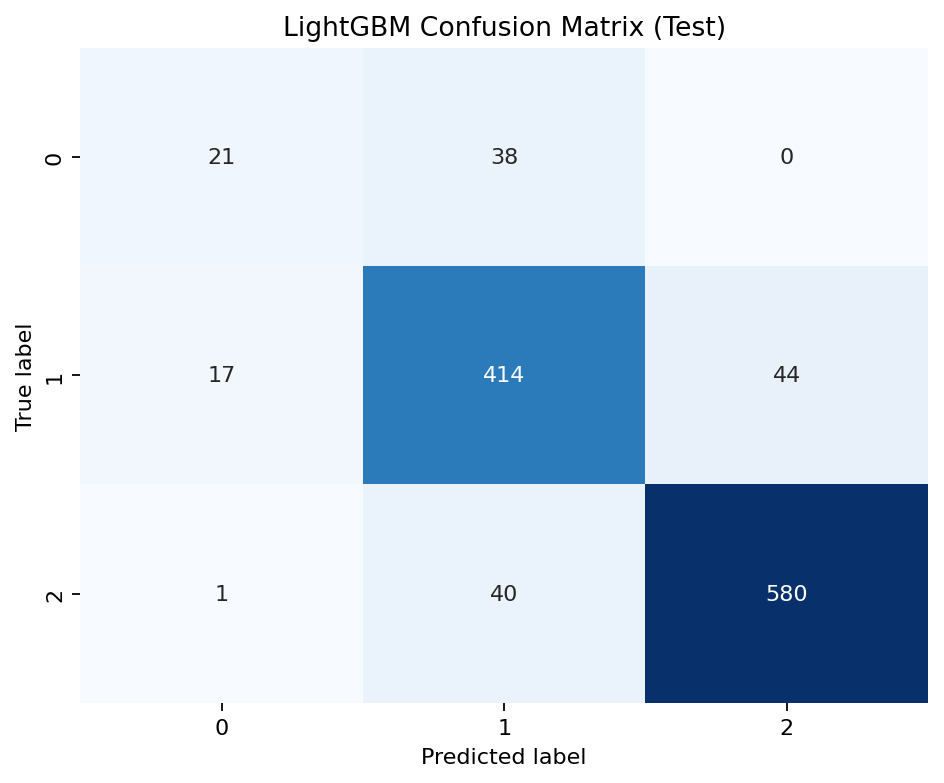

,0,1,2
0,21,38,0
1,17,414,44
2,1,40,580


Classification report (test set):
              precision    recall  f1-score   support

           0     0.5385    0.3559    0.4286        59
           1     0.8415    0.8716    0.8563       475
           2     0.9295    0.9340    0.9317       621

    accuracy                         0.8788      1155
   macro avg     0.7698    0.7205    0.7389      1155
weighted avg     0.8733    0.8788    0.8750      1155

--- TEST SET EVALUATION ---
Accuracy: 0.8788
Precision (Weighted): 0.8733
Recall (Weighted):    0.8788
F1-macro:            0.7389
F1-weighted:         0.8750
QWK (Quadratic Weighted Kappa): 0.8152
AUC: 0.9317
---------------------------
Saved: /kaggle/working/credit_rating_artifacts/lightgbm_test_confusion_matrix.png
Saved: /kaggle/working/credit_rating_artifacts/lightgbm_test_confusion_matrix.csv
Saved: /kaggle/working/credit_rating_artifacts/lightgbm_test_classification_report.csv
Saved: /kaggle/working/credit_rating_artifacts/lightgbm_test_classification_report.csv


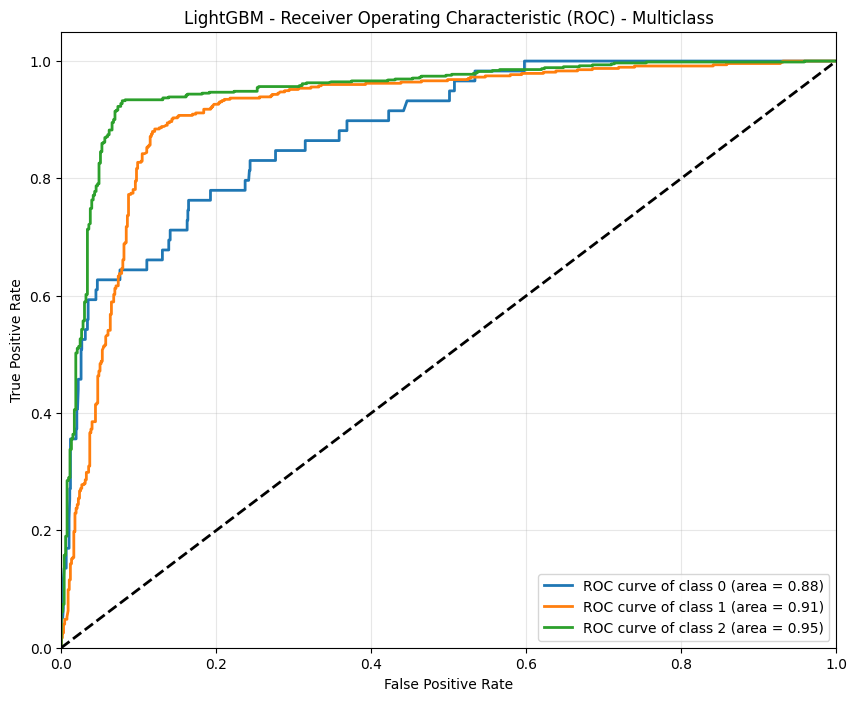

Saved: /kaggle/working/credit_rating_artifacts/lightgbm_test_roc_curves.png


In [4]:
id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(n_classes)}
class_labels = [str(id_to_raw_local.get(i, i)) for i in range(n_classes)]

cm = confusion_matrix(y_test, test_pred, labels=label_ids)
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

plt.figure(figsize=(6, 5), dpi=160)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('LightGBM Confusion Matrix (Test)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_plot_path = ARTIFACT_DIR / 'lightgbm_test_confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(cm_df)
print('Classification report (test set):')
print(classification_report(
    y_test,
    test_pred,
    labels=label_ids,
    target_names=class_labels,
    digits=4,
    zero_division=0,
))

cls_report_df = pd.DataFrame(
    classification_report(
        y_test,
        test_pred,
        labels=label_ids,
        target_names=class_labels,
        output_dict=True,
        zero_division=0,
    )
).transpose()

cm_csv_path = ARTIFACT_DIR / 'lightgbm_test_confusion_matrix.csv'
cls_csv_path = ARTIFACT_DIR / 'lightgbm_test_classification_report.csv'
cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')
cls_report_df.to_csv(cls_csv_path, encoding='utf-8-sig')

from sklearn.metrics import precision_score, recall_score

acc = accuracy_score(y_test, test_pred)
f1_macro = f1_score(y_test, test_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_test, test_pred, average='weighted', zero_division=0)
precision_weighted = precision_score(y_test, test_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, test_pred, average='weighted', zero_division=0)

try:
    y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
    auc_score = roc_auc_score(y_test_bin, test_proba, average='weighted', multi_class='ovr')
except:
    auc_score = float('nan')

qwk = cohen_kappa_score(y_test, test_pred, weights='quadratic')

print('--- TEST SET EVALUATION ---')
print(f'Accuracy: {acc:.4f}')
print(f'Precision (Weighted): {precision_weighted:.4f}')
print(f'Recall (Weighted):    {recall_weighted:.4f}')
print(f'F1-macro:            {f1_macro:.4f}')
print(f'F1-weighted:         {f1_weighted:.4f}')
print(f'QWK (Quadratic Weighted Kappa): {qwk:.4f}')
print(f'AUC: {auc_score:.4f}')
print('---------------------------')

metrics_summary = {
    'accuracy': acc,
    'precision_weighted': precision_weighted,
    'recall_weighted': recall_weighted,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'qwk': qwk,
    'auc': auc_score,
}

test_metrics_df = pd.DataFrame([metrics_summary])
test_metrics_path = ARTIFACT_DIR / 'lightgbm_test_classification_report.csv'
test_metrics_df.to_csv(test_metrics_path, index=False)

print('Saved:', cm_plot_path)
print('Saved:', cm_csv_path)
print('Saved:', cls_csv_path)
print(f'Saved: {test_metrics_path}')

id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(n_classes)}
class_labels = [str(id_to_raw_local.get(i, i)) for i in range(n_classes)]

plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc_val:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LightGBM - Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
roc_plot_path = ARTIFACT_DIR / 'lightgbm_test_roc_curves.png'
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', roc_plot_path)

## Visualization: Training Curves

Bieu do train/validation cho 5 metric: Loss, Accuracy, Macro F1, AUC, QWK.

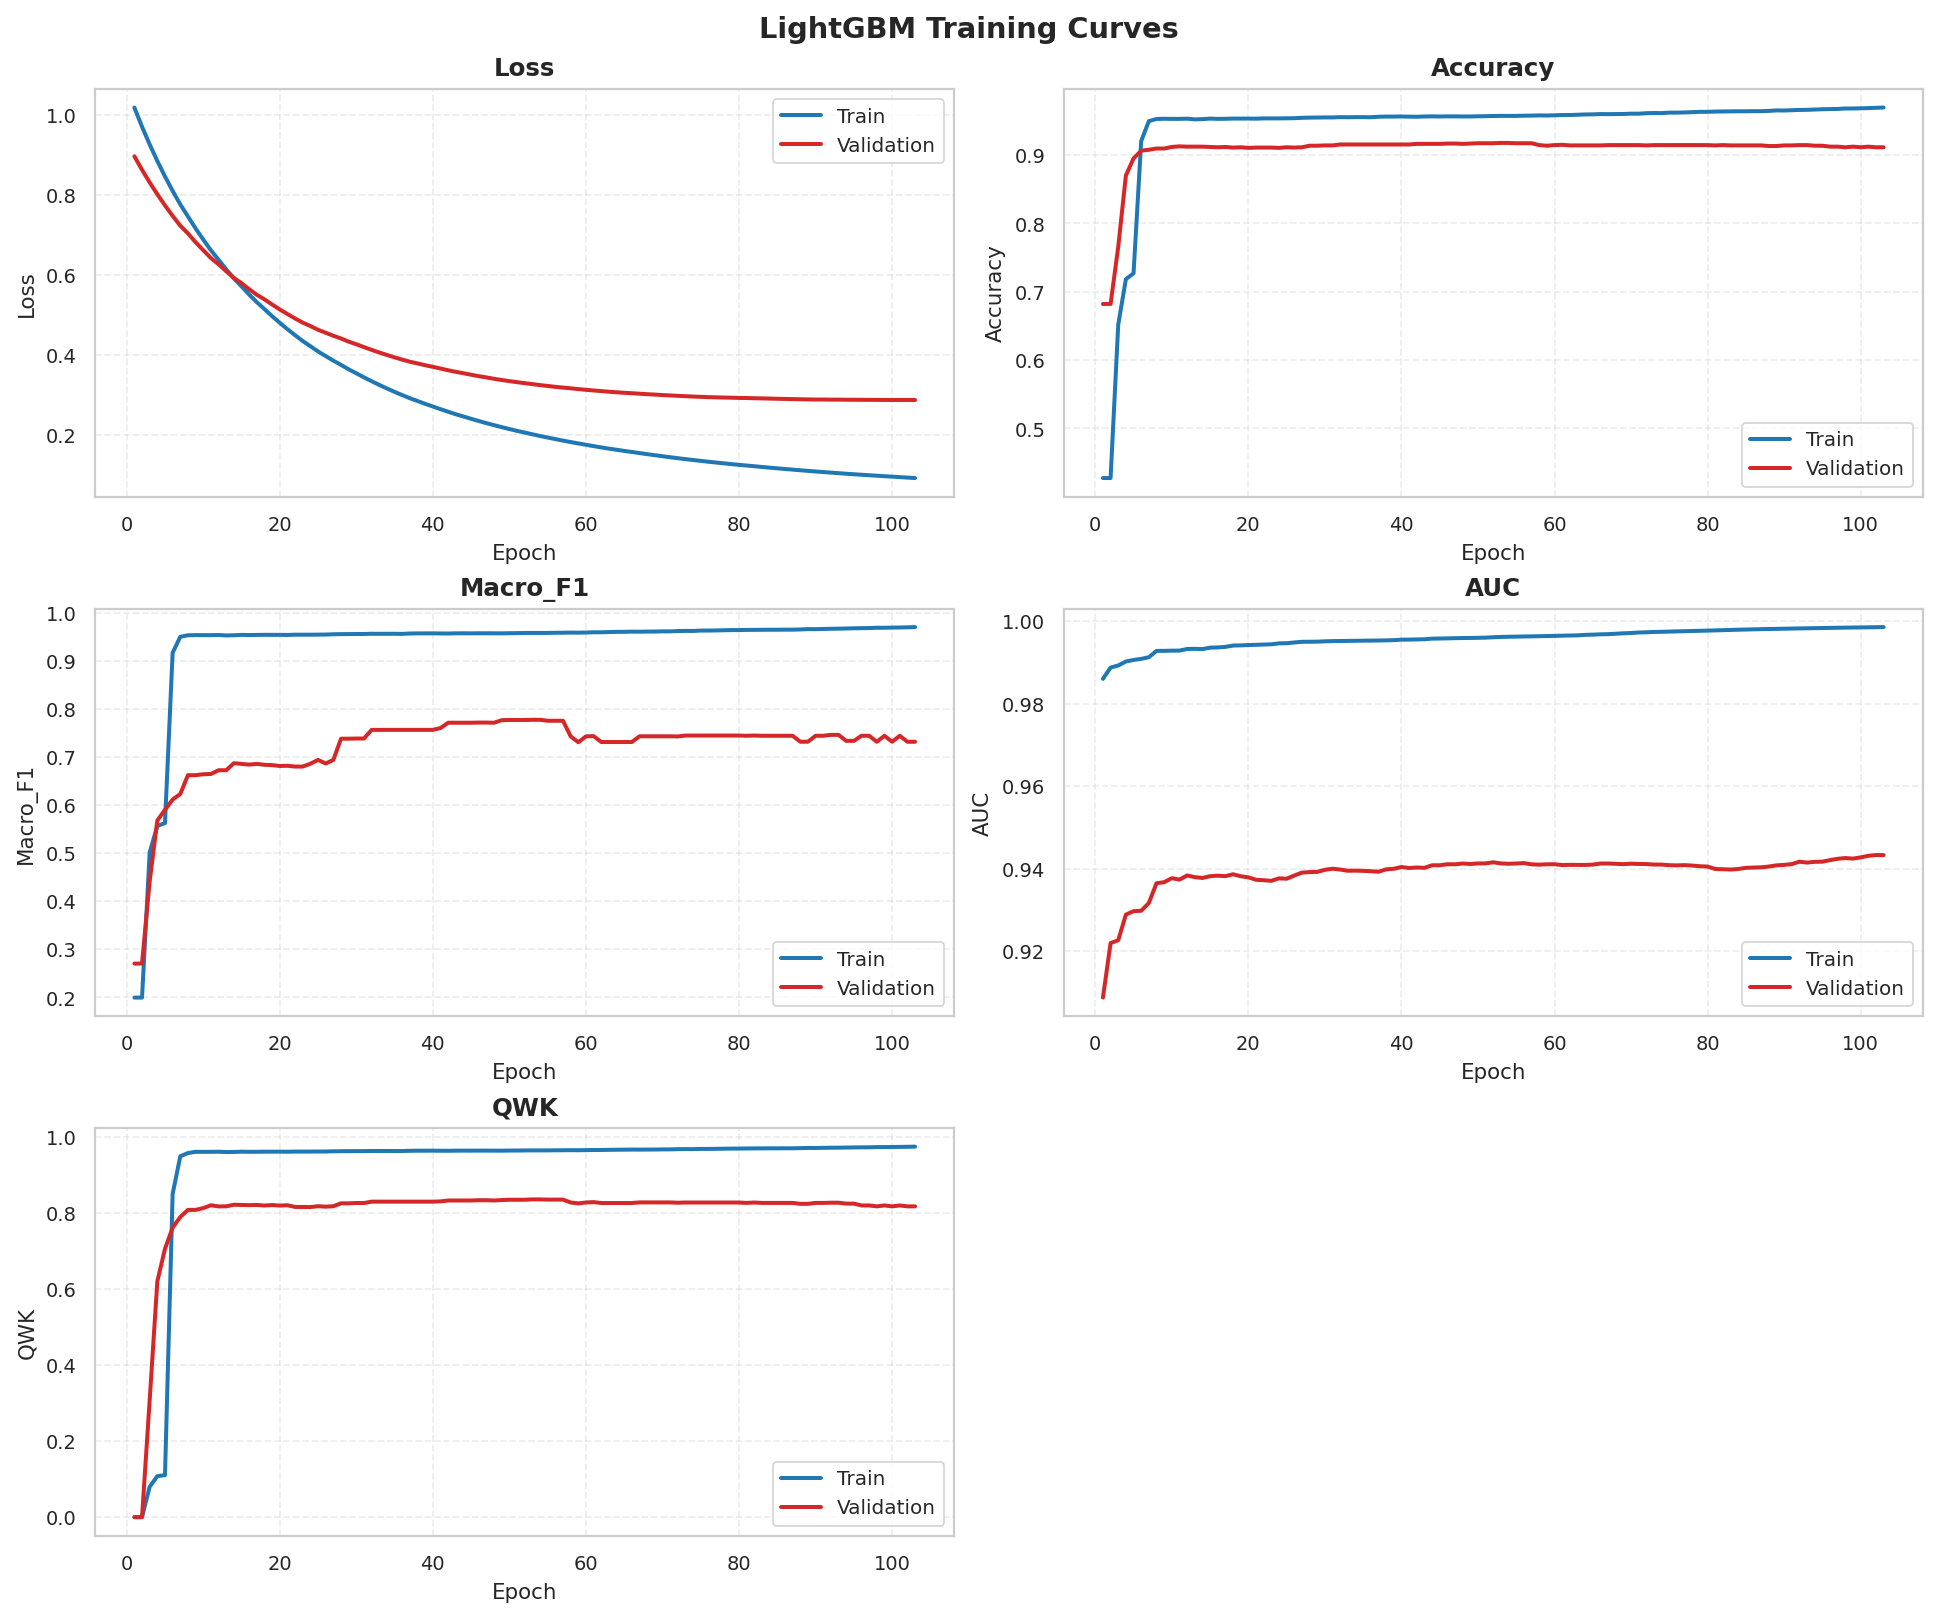

Saved: /kaggle/working/credit_rating_artifacts/lightgbm_training_curves.png


In [5]:
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

sns.set_theme(style='whitegrid', context='paper')
metrics = ['Loss', 'Accuracy', 'Macro_F1', 'AUC', 'QWK']
required_cols = [f'train_{m}' for m in metrics] + [f'val_{m}' for m in metrics]
missing = [c for c in required_cols if c not in history_df.columns]
if missing:
    raise RuntimeError(f'Thieu cot trong history_df: {missing}. Hay chay lai cell huan luyen.')

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=160, constrained_layout=True)
axes = axes.ravel()

for ax, metric in zip(axes, metrics):
    ax.plot(history_df['epoch'], history_df[f'train_{metric}'], label='Train', linewidth=1.8, color='#1f77b4')
    ax.plot(history_df['epoch'], history_df[f'val_{metric}'], label='Validation', linewidth=1.8, color='#d62728')
    ax.set_title(metric, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(frameon=True, fontsize=9)

for ax in axes[len(metrics):]:
    ax.axis('off')

fig.suptitle('LightGBM Training Curves', fontsize=13, fontweight='bold')
curve_path = ARTIFACT_DIR / 'lightgbm_training_curves.png'
fig.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', curve_path)

## Benchmark Comparison

Tong hop metric Val/Test giua LSTM, LightGBM, XGBoost (neu file metric da ton tai).

In [6]:
metric_sources = [
    ('LSTM', ARTIFACT_DIR / 'lstm_metrics.csv'),
    ('LightGBM', ARTIFACT_DIR / 'lightgbm_metrics.csv'),
    ('XGBoost', ARTIFACT_DIR / 'xgboost_metrics.csv'),
]

frames = []
for model_name, path in metric_sources:
    if path.exists():
        cur = pd.read_csv(path)
        cur['Model'] = model_name
        frames.append(cur)

if not frames:
    raise FileNotFoundError('Chua tim thay file metric nao de so sanh trong credit_rating_artifacts.')

comparison_df = pd.concat(frames, ignore_index=True)
comparison_df = comparison_df[['Model', 'Split', 'Accuracy', 'Macro_F1', 'AUC', 'QWK']]
comparison_df = comparison_df.sort_values(['Split', 'Macro_F1'], ascending=[True, False]).reset_index(drop=True)
display(comparison_df)

comparison_path = ARTIFACT_DIR / 'benchmark_model_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print('Saved:', comparison_path)

for split_name in ['Val', 'Test']:
    part = comparison_df[comparison_df['Split'].astype(str).str.lower() == split_name.lower()]
    if part.empty:
        continue
    best_row = part.sort_values('Macro_F1', ascending=False).iloc[0]
    print(f"Best {split_name} by Macro_F1: {best_row['Model']} ({best_row['Macro_F1']:.4f})")

,Model,Split,Accuracy,Macro_F1,AUC,QWK
0,LightGBM,Test,0.878788,0.738852,0.915493,0.815174
1,LightGBM,Val,0.911444,0.731847,0.943279,0.817965


Saved: /kaggle/working/credit_rating_artifacts/benchmark_model_comparison.csv
Best Val by Macro_F1: LightGBM (0.7318)
Best Test by Macro_F1: LightGBM (0.7389)
